# Testing Supervised MLP SAE with IID and OOD Recontruction

## Code Setup

In [1]:
# loads the widget backend for interactive plots
%matplotlib widget 

In [2]:
# automatically reload modules before executing code
%load_ext autoreload 
%autoreload 2 

In [3]:
# import libraries 
import numpy as np 
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import io, sys, re
from torch.utils.data import Dataset, DataLoader, TensorDataset
from src.sae import SAE   # SAE uses MLPEncoder when hidden_dim is given
from  src.sae import train_supervised_sae  # supervised SAE 
from tqdm.auto import trange, tqdm

# set device
device = torch.device('cuda')
device

device(type='cuda')

## 1) Configuration & source generation

In [4]:
seed = 42 # setting seed
C = np.inf  # faor later logistic regression
np.random.seed(seed)
torch.manual_seed(seed)

# make sources
z_01 = np.linspace(0, 1, 32) ** 2
z_01 = np.meshgrid(z_01, z_01)
z_01 = np.stack(z_01, 0).reshape(2, -1).T
z_01 = np.concatenate([z_01, np.zeros_like(z_01[:, :1])], 1)

z_02 = np.stack([z_01[:, 0], z_01[:, 2], z_01[:, 1]], 1)
z_12 = np.stack([z_01[:, 2], z_01[:, 0], z_01[:, 1]], 1)

print("Shapes:", z_01.shape, z_02.shape, z_12.shape)

Shapes: (1024, 3) (1024, 3) (1024, 3)


## 2) Visualize in 3D

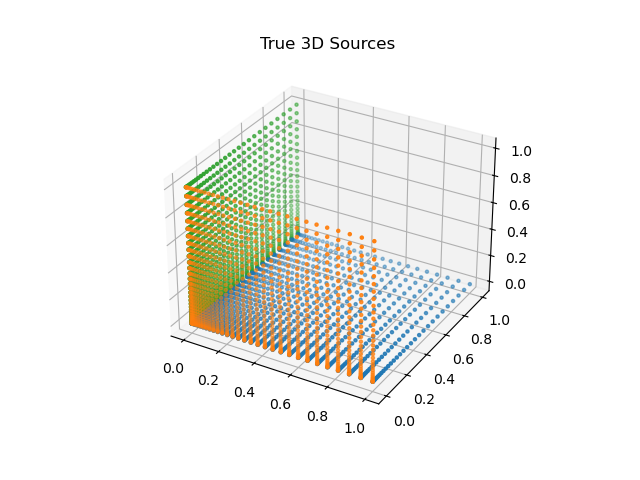

In [5]:
# 3 D plots
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*z_01.T, s=5)
ax.scatter(*z_02.T, s=5)
ax.scatter(*z_12.T, s=5)
ax.set_title("True 3D Sources")
plt.show()

## 3) Random 2D projection 

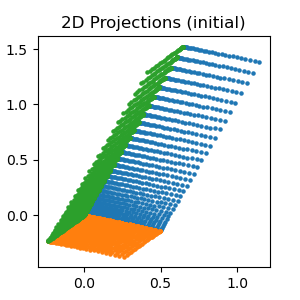

In [6]:
np.random.seed(seed)
A = np.random.normal(0, 1, (3, 2))

y_01 = z_01 @ A
y_02 = z_02 @ A
y_12 = z_12 @ A

s = 5
plt.figure(figsize=(3, 3))
plt.scatter(*y_01.T, s=s)
plt.scatter(*y_02.T, s=s)
plt.scatter(*y_12.T, s=s)
plt.title("2D Projections (initial)")
plt.show()

## 4) Train A via linear encoder + nonlinear decoder

In [7]:
inputs = np.concatenate([z_01, z_12, z_02], 0)

In [8]:
inputs.shape 

(3072, 3)

## 5) finding the best A matrix

In [9]:
inputs = torch.tensor(inputs, dtype=torch.float32, device=device)

best_loss = np.inf
best_A = None
num_seed = 10


for rep in range(num_seed):
    torch.manual_seed(seed + rep)
    encoder = nn.Linear(3, 2, bias=False).to(device)
    decoder = nn.Sequential(
        nn.Linear(2, 256),
        nn.ReLU(),
        nn.Linear(256, 3)
    ).to(device)
    optimizer = optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters()),
        lr=1e-3
    )

    for i in tqdm(range(10000), desc=f"Seed {rep}"):
        optimizer.zero_grad()
        y = encoder(inputs)
        rec = decoder(y)
        loss = torch.mean((inputs - rec) ** 2)
        loss.backward()
        optimizer.step()

    print(f"[Seed {rep}] loss = {loss.item():.6f}")
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_A = encoder.weight.detach().cpu().numpy().T
        if best_loss < 1e-4:
            break

# normalize learned A
A = best_A / np.linalg.norm(best_A, axis=1, keepdims=True)

Seed 0:   0%|          | 0/10000 [00:00<?, ?it/s]

[Seed 0] loss = 0.000011


## 6) Reproject with learned A & visualize

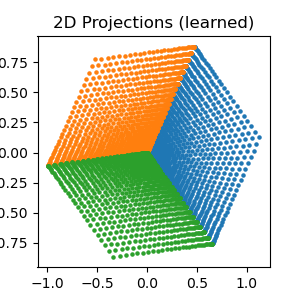

In [10]:
y_01 = z_01 @ A
y_02 = z_02 @ A
y_12 = z_12 @ A

plt.figure(figsize=(3, 3))
plt.scatter(*y_01.T, s=s)
plt.scatter(*y_02.T, s=s)
plt.scatter(*y_12.T, s=s)
plt.title("2D Projections (learned)")
plt.show()


## 7) Stack & split IID vs OOD

In [11]:
latent_all = np.concatenate([z_01, z_12, z_02], axis=0) # (3N,3) # same as inputs
proj_all   = latent_all @ A                               # (3N,2) # 2D projections of the input should be the same as a plot above

n_samples = z_01.shape[0]
print("Shapes:", z_01.shape, z_02.shape, z_12.shape)

split_idx  = 2 * n_samples # 67-33 Split 
latent_iid = latent_all[:split_idx]
proj_iid   = proj_all[:split_idx]
latent_ood = latent_all[split_idx:] 
proj_ood   = proj_all[split_idx:]

inputs_iid  = torch.tensor(proj_iid,   dtype=torch.float32, device=device) # 2D input
targets_iid = torch.tensor(latent_iid, dtype=torch.float32, device=device) # 3D latent
inputs_ood  = torch.tensor(proj_ood,   dtype=torch.float32, device=device)
targets_ood = torch.tensor(latent_ood, dtype=torch.float32, device=device)

label_binary = latent_all > .5 
label_iid = label_binary[:split_idx]
label_ood = label_binary[split_idx:]

train_ds = TensorDataset(inputs_iid, targets_iid) 

# 3) Pass it in
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True) 


# The goal is to go from 2D inputs to 3D latent space, trying to invert the projection A

Shapes: (1024, 3) (1024, 3) (1024, 3)


## 8) Supervised SAE  

In [12]:
model   = SAE(input_dim=2, hidden_dim = 256, latent_dim=3).to(device) # Created a SAE with a hidden layer of size 256, good practice to define variable named hidden_dim = 256 
enc_sup = model.encoder
dec_sup = model.decoder

num_epochs = 50  # number of epochs to train 

# train the supervised encoder 
print(device)

history, Z_pred_iid, Z_pred_ood = train_supervised_sae( 
    model,
    train_loader,
    inputs_iid, targets_iid,
    inputs_ood, targets_ood,
    device,
    lr=1e-3,
    num_epochs=num_epochs)

cuda


Sup SAE Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 46/50:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 47/50:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 48/50:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/32 [00:00<?, ?it/s]

## Plot Results

- Plot `history` (MSE) and `num_epochs`
- plot `latent_all` and `Z_all_pred`
- Plot `targets_iid` and `Z_iid_pred`
- Plot `targets_ood` and `Z_ood_pred`

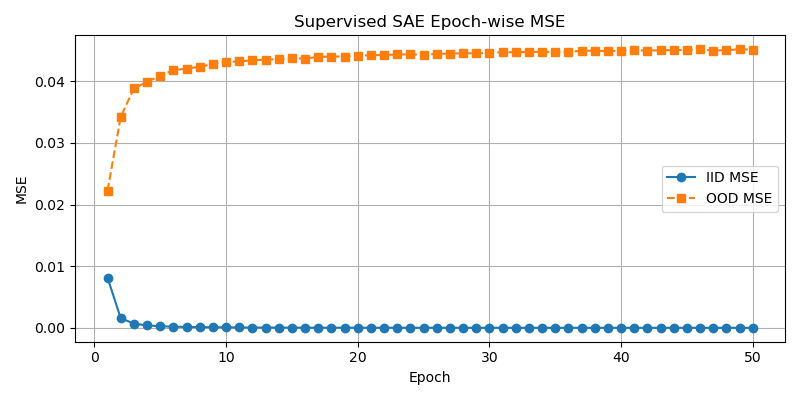

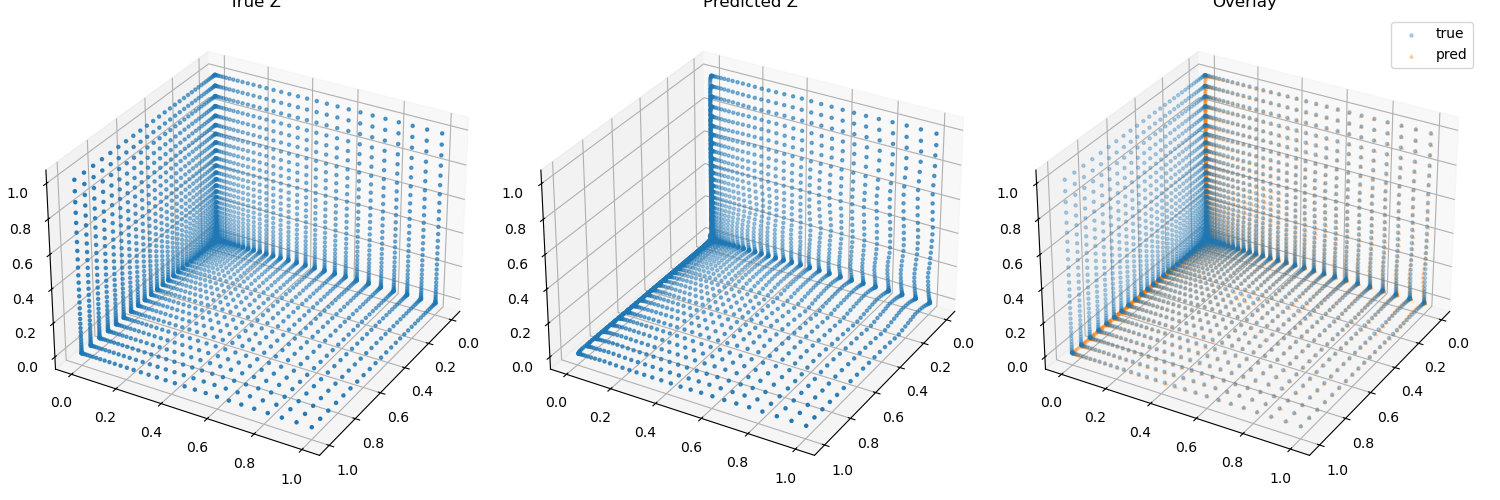

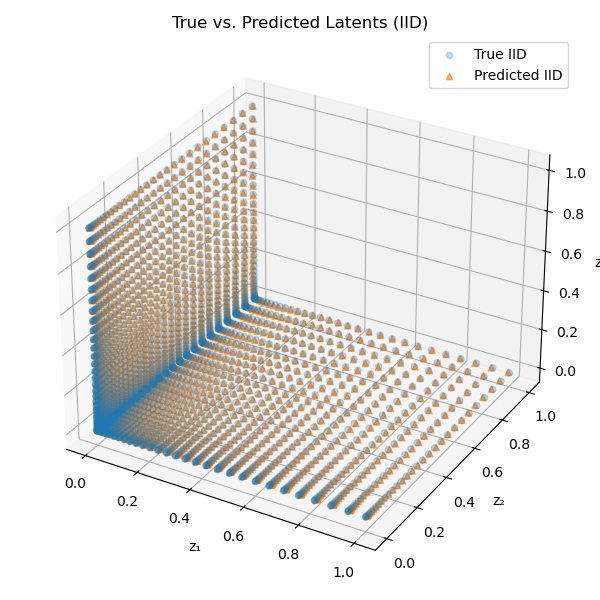

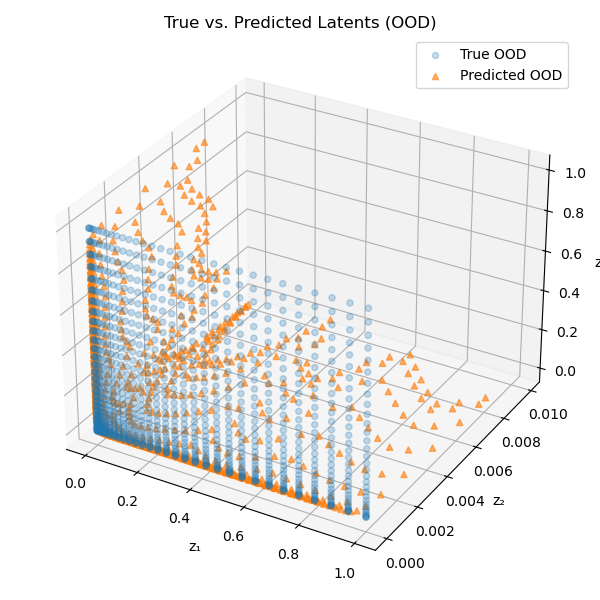

In [13]:
from src.sae_plots import (
    plot_mse_vs_epoch,
    plot_latent_comparison,
    plot_iid_latents,
    plot_ood_latents
)

# combine into one array for plotting 
Z_all_pred = np.vstack([
    Z_pred_iid,
    Z_pred_ood
])

# plotting the results
plot_mse_vs_epoch(history, num_epochs)
plot_latent_comparison(latent_all, Z_all_pred)
plot_iid_latents(targets_iid, Z_pred_iid)
plot_ood_latents(targets_ood, Z_pred_ood)

## Evaluating the accuracy of the supervised SAE with and without MLP

In [13]:
import numpy as np
import torch

def _pearson_corr_1d(x: np.ndarray, y: np.ndarray) -> float:
    # assumes len(x) == len(y) >= 2
    x = x.astype(np.float64, copy=False)
    y = y.astype(np.float64, copy=False)
    x -= x.mean()
    y -= y.mean()
    denom = np.sqrt((x * x).sum()) * np.sqrt((y * y).sum())
    if denom == 0.0:
        return np.nan
    return float((x * y).sum() / denom)

def safe_mcc_ignore_zeros(x, y, method: str = 'pearson', reduce: str = 'mean') -> float:
    """
    Compute correlation while EXCLUDING entries that are exactly zero.
    - If reduce='mean': compute per-column corr (ignoring zeros) then average.
    - If reduce='global': flatten arrays and ignore all zero entries.
    Returns 0.0 if nothing valid remains after masking.
    """
    # Convert to numpy
    x_np = x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)
    y_np = y.detach().cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)

    if x_np.shape != y_np.shape:
        raise ValueError(f"Shape mismatch: {x_np.shape} vs {y_np.shape}")

    # Treat NaNs as zeros (so they get excluded)
    x_np = np.nan_to_num(x_np, nan=0.0)
    y_np = np.nan_to_num(y_np, nan=0.0)

    if reduce == 'global':
        mask = (x_np != 0) & (y_np != 0)
        xv = x_np[mask]
        yv = y_np[mask]
        if xv.size < 2:
            return 0.0
        s = _pearson_corr_1d(xv, yv)
        return 0.0 if np.isnan(s) else float(s)

    # Per-column correlation: shape (D, N)
    if x_np.ndim == 1:
        return safe_mcc_ignore_zeros(x_np, y_np, method=method, reduce='global')

    D, N = x_np.shape
    corrs = []
    for j in range(N):
        mask = (x_np[:, j] != 0) & (y_np[:, j] != 0)
        if mask.sum() < 2:
            corrs.append(np.nan)
            continue
        xj = x_np[mask, j]
        yj = y_np[mask, j]
        if method == 'pearson':
            c = _pearson_corr_1d(xj, yj)
        elif method == 'spearman':
            rx = xj.argsort().argsort().astype(np.float64)
            ry = yj.argsort().argsort().astype(np.float64)
            c = _pearson_corr_1d(rx, ry)
        else:
            raise ValueError(f"Unsupported method: {method}")
        corrs.append(c)

    m = np.nanmean(corrs) if corrs else np.nan
    return 0.0 if np.isnan(m) else float(m)

In [14]:
# After training finishes (or inside each epoch for tracking):
# Z_pred_iid, Z_pred_ood: outputs from your model (same shapes as targets)
# targets_iid, targets_ood: ground truth latent codes

iid_mcc = safe_mcc_ignore_zeros(Z_pred_iid, targets_iid, method='pearson')
ood_mcc = safe_mcc_ignore_zeros(Z_pred_ood, targets_ood, method='pearson')
print(f"IID MCC: {iid_mcc:.4f}, OOD MCC: {ood_mcc:.4f}") 

IID MCC: 0.8930, OOD MCC: 0.9106


In [15]:
# Per-dimension logistic regression accuracy
from src.acc import compute_per_dim_accuracy

# after you have Z_pred_iid, Z_pred_ood, label_iid, label_ood…
acc_iid_list, acc_ood_list = compute_per_dim_accuracy(
    Z_pred_iid, Z_pred_ood,
    label_iid,  label_ood,
    max_iter=1000
)

print("Per-dim IID acc:", acc_iid_list)
print("Per-dim OOD acc:", acc_ood_list)

Per-dim IID acc: [0.97705078125, 0.9208984375, 0.962890625]
Per-dim OOD acc: [0.8564453125, 1.0, 0.8740234375]


## Saving Results

In [16]:
#import os
from src.saving_data import save_sae_run # saving data function

# after training…
path = save_sae_run(
    A,
    inputs_iid, targets_iid,
    inputs_ood, targets_ood,
    Z_pred_iid, Z_pred_ood,
    history,
    mlp=True,
    epochs=num_epochs,
    seed=seed,
    hidden_dim=256,
    accuracy_iid=acc_iid_list,
    accuracy_ood=acc_ood_list,
    out_dir='results'
)

print("Saved run data to:", path)


Saved run data to: results/sae_mlp_epochs_50_seed_42_hidden_256.pt
